In [ ]:
pip install cobra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.3 MB/s eta 0:00:00


In [ ]:
#importing necessary libraries
import numpy as np
import pandas as pd
import re
import cobra
import matplotlib.pyplot as plt

In [ ]:
# Gene identifiers
gene_f=input('Enter the file path for the gene identifier file')
gene_names=pd.read_csv(gene_f)
gene_names.head()

Enter the file path for the gene identifier file/content/gene_identifiers.csv


,gene_number,symbol,ensembl_gene,entrez_id
0,8639.1,AOC3,ENSG00000131471,8639.0
1,26.1,AOC1,ENSG00000002726,26.0
2,314.2,AOC2,ENSG00000131480,314.0
3,314.1,AOC2,ENSG00000131480,314.0
4,1591.1,CYP24A1,ENSG00000019186,1591.0


In [ ]:
# Load the required model
model_filepath=input("Enter the file path for the model compared:")
model=cobra.io.load_matlab_model(model_filepath)

# Load the FVA bounds
studied_f=input("Enter the file path for the FVA values of the model under study:")
control_f=input("Enter the file path for the FVA values of the control model:")
compared=pd.read_csv(studied_f)
control=pd.read_csv(control_f)

Enter the file path for the model compared:/content/mkn28_6_updated.mat


Enter the file path for the FVA values of the model under study:/content/mkn28_6_updated_flux_variability.csv
Enter the file path for the FVA values of the control model:/content/mkn28_2_updated_flux_variability.csv


In [ ]:
#run only ones
#control['ReactionID']='human'+control['ReactionID']
#control.head()

,ReactionID,minFlux,maxFlux
0,human10FTHF7GLUtl,0.000000,0.000006
1,human10FTHF7GLUtm,0.000000,0.000006
2,human10FTHFtl,-0.000006,0.000000
3,human10FTHFtm,-0.029961,-0.016103
4,human13DAMPPOX,0.000000,0.000008


In [ ]:
def reaction_gene_linker(infected,control,model):
  infect=input("Enter the identity of the model compared")
  cont=input("Enter the identity of the control model")
  # Flux spans
  control["FluxSpan"]  = control["maxFlux"]  - control["minFlux"]
  infected["FluxSpan"] = infected["maxFlux"] - infected["minFlux"]

  # Merge
  merged = pd.merge(
      control[["ReactionID","FluxSpan"]].rename(columns={"FluxSpan":"FluxSpan_control"}),
      infected[["ReactionID","FluxSpan"]].rename(columns={"FluxSpan":"FluxSpan_infected"}),
      on="ReactionID", how="inner"
  )


  # Guard for tiny spans to avoid blow-ups
  eps = 1e-9
  merged["FSR"] = (merged["FluxSpan_infected"] + eps) / (merged["FluxSpan_control"] + eps)

  # Classify using ratio thresholds
  def classify_ratio(x):
      if np.isnan(x): return "undefined"
      if x > 2.0:     return "Upregulated"      # increased variability
      if x < 0.8:     return "Downregulated"    # decreased variability
      return "No change"

  merged["Interpretation"] = merged["FSR"].apply(classify_ratio)

  # Counts (vectorized)
  counts = merged["Interpretation"].value_counts()
  print(counts)

  try:

      print(f"Successfully loaded model: {model.id} with {len(model.reactions)} reactions.")
  except FileNotFoundError:
      print("Error: Model file not found. Check the path.")
  except Exception as e:
      print(f"Error loading MATLAB model: {e}")
      print("\nTip: If you don't know the variable_name, try removing the 'variable_name' argument, or open the .mat file in MATLAB/SciPy to check the structure.")

  # 2. You can then proceed with the rest of your mapping code:
  def get_reaction_info(reaction_id):
      # ... (function body remains the same as before)
      if reaction_id in model.reactions:
          rxn = model.reactions.get_by_id(reaction_id)
          gpr = rxn.gene_reaction_rule
          rxnname=rxn.name
          subsystem = rxn.subsystem if rxn.subsystem else "Unassigned"
          return pd.Series([rxnname, subsystem,gpr])
      else:
          return pd.Series(["Not found in model", "Not found in model"])

  merged[['Reaction Names', 'Subsystem','GPR']] = merged['ReactionID'].apply(get_reaction_info)

  fsr = merged.sort_values(by='FSR', ascending=False)

  def extract_entrez_ids(gpr_rule):
      """
      Parses the GPR rule string to extract all unique Entrez Gene IDs.

      The pattern captures digits followed by '_AT1' or similar suffixes.
      It returns a list of unique Entrez IDs (the number part).
      """
      if pd.isna(gpr_rule) or gpr_rule == "Not found in model":
          return []
      # Use regular expression to find all numbers followed by _AT1 (or just the number part)
      # The pattern looks for one or more digits (\d+) followed by an optional suffix (_[A-Za-z0-9]+)
      # The Entrez ID is the number itself.
      gene_ids_with_suffix = re.findall(r'(\d+)_AT\d+', str(gpr_rule))
      unique_ids = set(gene_ids_with_suffix)
      return sorted(list(unique_ids))

  gene_names['entrez_id_clean'] = (gene_names['entrez_id'].fillna(0.0).astype(float).astype(int).astype(str))
  entrez_to_symbol_map = dict(zip(gene_names['entrez_id_clean'], gene_names['symbol']))


  def gpr_entrez_to_symbol(gpr_rule, entrez_to_symbol_map):
    """
    Convert a GPR rule like '6307_AT1 or 10826_AT1' into 'FAXDC2 or MSMO1'
    Preserves 'and', 'or', parentheses. Only replaces gene tokens.
    """
    if pd.isna(gpr_rule) or gpr_rule in ["Not found in model", "No rule present in the model", ""]:
        return gpr_rule

    s = str(gpr_rule)

    # Replace tokens like 55907_AT1 / 55907_AT2 / 55907_AT10 etc.
    def repl(m):
        entrez = m.group(1)  # numeric part
        sym = entrez_to_symbol_map.get(entrez, f"UNKNOWN_{entrez}")
        return sym

    s2 = re.sub(r"\b(\d+)_AT\d+\b", repl, s)
    return s2
  # Create the new column
  fsr["GPR_new"] = fsr["GPR"].apply(lambda x: gpr_entrez_to_symbol(x, entrez_to_symbol_map))

  fsr['Entrez_IDs'] = fsr['GPR'].apply(extract_entrez_ids)


  gene_names['entrez_id_clean'] = gene_names['entrez_id'].fillna(0.0).astype(float).astype(int).astype(str)
  # Create a mapping dictionary: {'Entrez_ID_String': 'Symbol'}
  # Example: {'8639': 'AOC3', '26': 'AOC1', ...}
  entrez_to_symbol_map = dict(zip(gene_names['entrez_id_clean'], gene_names['symbol']))


  # --- 2. Function to Map List of IDs to Symbols (Same as before, ensuring string comparison) ---
  def map_ids_to_symbols(entrez_list):
      """
      Maps a list of Entrez IDs (clean strings) to their corresponding gene symbols.
      """
      if not entrez_list:
          return []
      symbols = []
      for entrez_id in entrez_list:
          # entez_id here is already a clean string (e.g., '4830') from the previous parsing step.
          symbol = entrez_to_symbol_map.get(entrez_id, f"UNKNOWN_{entrez_id}")
          symbols.append(symbol)

      # Join the symbols into a single string for display
      return ' , '.join(symbols)

  # --- 3. Apply the mapping to the filtered DataFrame ---

  # The 'Entrez_IDs' column is applied to the function.
  fsr['Gene_Symbols'] = fsr['Entrez_IDs'].apply(map_ids_to_symbols)
  for i in range(len(fsr)):
    if fsr["GPR"].iloc[i]==[]:
      fsr["GPR"].iloc[i]='No rule present in the model'
      fsr["Entrez_IDs"].iloc[i]='No information'
      fsr["Gene_Symbols"].iloc[i]='No information'
    else:
      if fsr["Gene_Symbols"].iloc[i]==[]:
        fsr["Gene_Symbols"].iloc[i]='Gene unidentified'

  copy_up=fsr[fsr["Interpretation"]=='Upregulated']
  copy_down=fsr[fsr["Interpretation"]=='Downregulated']
  copy_up.to_csv('fsr_mapping_'+infect+'__Vs__'+cont+'upregulated_raw_file.csv',index=False)
  copy_down.to_csv('fsr_mapping_'+infect+'__Vs__'+cont+'downregulated_raw_file.csv',index=False)
  return counts



In [ ]:
def reaction_gene_linker(infected,control,model):
  infect=input("Enter the identity of the model compared")
  cont=input("Enter the identity of the control model")
  # Flux spans
  control["FluxSpan"]  = control["maxFlux"]  - control["minFlux"]
  infected["FluxSpan"] = infected["maxFlux"] - infected["minFlux"]

  # Merge
  merged = pd.merge(
      control[["ReactionID","FluxSpan"]].rename(columns={"FluxSpan":"FluxSpan_control"}),
      infected[["ReactionID","FluxSpan"]].rename(columns={"FluxSpan":"FluxSpan_infected"}),
      on="ReactionID", how="inner"
  )


  # Guard for tiny spans to avoid blow-ups
  eps = 1e-9
  merged["FSR"] = (merged["FluxSpan_infected"] + eps) / (merged["FluxSpan_control"] + eps)

  # Classify using ratio thresholds
  def classify_ratio(x):
      if np.isnan(x): return "undefined"
      if x > 2.0:     return "Upregulated"      # increased variability
      if x < 0.5:     return "Downregulated"    # decreased variability
      return "No change"

  merged["Interpretation"] = merged["FSR"].apply(classify_ratio)

  # Counts (vectorized)
  counts = merged["Interpretation"].value_counts()
  print(counts)

  try:

      print(f"Successfully loaded model: {model.id} with {len(model.reactions)} reactions.")
  except FileNotFoundError:
      print("Error: Model file not found. Check the path.")
  except Exception as e:
      print(f"Error loading MATLAB model: {e}")
      print("\nTip: If you don't know the variable_name, try removing the 'variable_name' argument, or open the .mat file in MATLAB/SciPy to check the structure.")

  # 2. You can then proceed with the rest of your mapping code:
  def get_reaction_info(reaction_id):
      # ... (function body remains the same as before)
      if reaction_id in model.reactions:
          rxn = model.reactions.get_by_id(reaction_id)
          gpr = rxn.gene_reaction_rule
          rxnname=rxn.name
          subsystem = rxn.subsystem if rxn.subsystem else "Unassigned"
          return pd.Series([rxnname, subsystem,gpr])
      else:
          return pd.Series(["Not found in model", "Not found in model"])

  merged[['Reaction Names', 'Subsystem','GPR']] = merged['ReactionID'].apply(get_reaction_info)

  fsr = merged.sort_values(by='FSR', ascending=False)

  def extract_entrez_ids(gpr_rule):
      """
      Parses the GPR rule string to extract all unique Entrez Gene IDs.

      The pattern captures digits followed by '_AT1' or similar suffixes.
      It returns a list of unique Entrez IDs (the number part).
      """
      if pd.isna(gpr_rule) or gpr_rule == "Not found in model":
          return []
      # Use regular expression to find all numbers followed by _AT1 (or just the number part)
      # The pattern looks for one or more digits (\d+) followed by an optional suffix (_[A-Za-z0-9]+)
      # The Entrez ID is the number itself.
      gene_ids_with_suffix = re.findall(r'(\d+).\d+', str(gpr_rule))
      unique_ids = set(gene_ids_with_suffix)
      return sorted(list(unique_ids))

  gene_names['entrez_id_clean'] = (gene_names['entrez_id'].fillna(0.0).astype(float).astype(int).astype(str))
  entrez_to_symbol_map = dict(zip(gene_names['entrez_id_clean'], gene_names['symbol']))


  def gpr_entrez_to_symbol(gpr_rule, entrez_to_symbol_map):
    """
    Convert a GPR rule like '6307_AT1 or 10826_AT1' into 'FAXDC2 or MSMO1'
    Preserves 'and', 'or', parentheses. Only replaces gene tokens.
    """
    if pd.isna(gpr_rule) or gpr_rule in ["Not found in model", "No rule present in the model", ""]:
        return gpr_rule

    s = str(gpr_rule)

    # Replace tokens like 55907_AT1 / 55907_AT2 / 55907_AT10 etc.
    def repl(m):
        entrez = m.group(1)  # numeric part
        sym = entrez_to_symbol_map.get(entrez, f"UNKNOWN_{entrez}")
        return sym

    s2 = re.sub(r"\b(\d+).\d+\b", repl, s)
    return s2
  # Create the new column
  fsr["GPR_new"] = fsr["GPR"].apply(lambda x: gpr_entrez_to_symbol(x, entrez_to_symbol_map))

  fsr['Entrez_IDs'] = fsr['GPR'].apply(extract_entrez_ids)


  gene_names['entrez_id_clean'] = gene_names['entrez_id'].fillna(0.0).astype(float).astype(int).astype(str)
  # Create a mapping dictionary: {'Entrez_ID_String': 'Symbol'}
  # Example: {'8639': 'AOC3', '26': 'AOC1', ...}
  entrez_to_symbol_map = dict(zip(gene_names['entrez_id_clean'], gene_names['symbol']))


  # --- 2. Function to Map List of IDs to Symbols (Same as before, ensuring string comparison) ---
  def map_ids_to_symbols(entrez_list):
      """
      Maps a list of Entrez IDs (clean strings) to their corresponding gene symbols.
      """
      if not entrez_list:
          return []
      symbols = []
      for entrez_id in entrez_list:
          # entez_id here is already a clean string (e.g., '4830') from the previous parsing step.
          symbol = entrez_to_symbol_map.get(entrez_id, f"UNKNOWN_{entrez_id}")
          symbols.append(symbol)

      # Join the symbols into a single string for display
      return ' , '.join(symbols)

  # --- 3. Apply the mapping to the filtered DataFrame ---

  # The 'Entrez_IDs' column is applied to the function.
  fsr['Gene_Symbols'] = fsr['Entrez_IDs'].apply(map_ids_to_symbols)
  for i in range(len(fsr)):
    if fsr["GPR"].iloc[i]==[]:
      fsr["GPR"].iloc[i]='No rule present in the model'
      fsr["Entrez_IDs"].iloc[i]='No information'
      fsr["Gene_Symbols"].iloc[i]='No information'
    else:
      if fsr["Gene_Symbols"].iloc[i]==[]:
        fsr["Gene_Symbols"].iloc[i]='Gene unidentified'

  copy_up=fsr[fsr["Interpretation"]=='Upregulated']
  copy_down=fsr[fsr["Interpretation"]=='Downregulated']
  copy_up.to_csv('fsr_mapping_'+infect+'__Vs__'+cont+'upregulated_raw_file.csv',index=False)
  copy_down.to_csv('fsr_mapping_'+infect+'__Vs__'+cont+'downregulated_raw_file.csv',index=False)
  return counts

In [ ]:
#testing
yaa=reaction_gene_linker(compared,control,model)
yaa

Enter the identity of the model comparedMKN6
Enter the identity of the control modelMKN0
Interpretation
No change        6099
Downregulated     719
Upregulated       556
Name: count, dtype: int64
Successfully loaded model: model_new3 with 7553 reactions.


Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  fsr["Gene_Symbols"].iloc[i]='Gene unidentified'
/tmp/ipykernel_5062/3541277974.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fsr["Gene_Symbols"].iloc[i]='Gene unidentified'
/tmp/ipykernel_5062/3541277974.py:135: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy

,count
Interpretation,
No change,6099
Downregulated,719
Upregulated,556


In [ ]:
def reaction_gene_linker(infected,control,model):
  infect=input("Enter the identity of the model compared")
  cont=input("Enter the identity of the control model")
  # Flux spans
  control["FluxSpan"] = control["maxFlux"] - control["minFlux"]
  infected["FluxSpan"] = infected["maxFlux"] - infected["minFlux"]

  # --- 2. Merge DataFrames (from first snippet) ---
  merged = pd.merge(
      control[["ReactionID", "minFlux", "maxFlux", "FluxSpan"]].rename(
          columns={"FluxSpan": "FluxSpan_control", "minFlux": "minFlux_control", "maxFlux": "maxFlux_control"}
      ),
      infected[["ReactionID", "minFlux", "maxFlux", "FluxSpan"]].rename(
          columns={"FluxSpan": "FluxSpan_infected", "minFlux": "minFlux_infected", "maxFlux": "maxFlux_infected"}
      ),
      on="ReactionID",
      how="inner",
  )

  # --- 3. Apply Conditional Logic (from second snippet) using Vectorization ---
  # Initialize the new column
  merged["FSR"] = np.nan

  # Condition 1: max fluxes are different AND infected min <= control min
  cond1 = (merged["maxFlux_infected"] != merged["maxFlux_control"]) & \
          (merged["minFlux_infected"] <= merged["minFlux_control"])

  # Condition 2: max fluxes are the same AND min fluxes are the same (identical range)
  cond2 = (merged["maxFlux_infected"] == merged["maxFlux_control"]) & \
          (merged["minFlux_infected"] == merged["minFlux_control"])

  # Apply the ratio calculation for Condition 1
  merged.loc[cond1, "FSR"] = \
      merged["FluxSpan_infected"] / merged["FluxSpan_control"]

  # Apply the 0 assignment for Condition 2
  merged.loc[cond2, "FSR"] = 0


  # Guard for tiny spans to avoid blow-ups
  eps = 1e-9


  # Classify using ratio thresholds
  def classify_ratio(x):
      if np.isnan(x): return "undefined"
      if x > 2.0:     return "Upregulated"      # increased variability
      if x < 0.5 and x > 0:     return "Downregulated"    # decreased variability
      return "No change"

  merged["Interpretation"] = merged["FSR"].apply(classify_ratio)

  # Counts (vectorized)
  counts = merged["Interpretation"].value_counts()
  print(counts)

  try:

      print(f"Successfully loaded model: {model.id} with {len(model.reactions)} reactions.")
  except FileNotFoundError:
      print("Error: Model file not found. Check the path.")
  except Exception as e:
      print(f"Error loading MATLAB model: {e}")
      print("\nTip: If you don't know the variable_name, try removing the 'variable_name' argument, or open the .mat file in MATLAB/SciPy to check the structure.")

  # 2. You can then proceed with the rest of your mapping code:
  def get_reaction_info(reaction_id):
      # ... (function body remains the same as before)
      if reaction_id in model.reactions:
          rxn = model.reactions.get_by_id(reaction_id)
          gpr = rxn.gene_reaction_rule
          rxnname=rxn.name
          subsystem = rxn.subsystem if rxn.subsystem else "Unassigned"
          return pd.Series([rxnname, subsystem,gpr])
      else:
          return pd.Series(["Not found in model", "Not found in model"])

  merged[['Reaction Names', 'Subsystem','GPR']] = merged['ReactionID'].apply(get_reaction_info)

  fsr = merged.sort_values(by='FSR', ascending=False)

  def extract_entrez_ids(gpr_rule):
      """
      Parses the GPR rule string to extract all unique Entrez Gene IDs.

      The pattern captures digits followed by '_AT1' or similar suffixes.
      It returns a list of unique Entrez IDs (the number part).
      """
      if pd.isna(gpr_rule) or gpr_rule == "Not found in model":
          return []
      # Use regular expression to find all numbers followed by _AT1 (or just the number part)
      # The pattern looks for one or more digits (\d+) followed by an optional suffix (_[A-Za-z0-9]+)
      # The Entrez ID is the number itself.
      gene_ids_with_suffix = re.findall(r'(\d+).\d+', str(gpr_rule))
      unique_ids = set(gene_ids_with_suffix)
      return sorted(list(unique_ids))

  gene_names['entrez_id_clean'] = (gene_names['entrez_id'].fillna(0.0).astype(float).astype(int).astype(str))
  entrez_to_symbol_map = dict(zip(gene_names['entrez_id_clean'], gene_names['symbol']))


  def gpr_entrez_to_symbol(gpr_rule, entrez_to_symbol_map):
    """
    Convert a GPR rule like '6307_AT1 or 10826_AT1' into 'FAXDC2 or MSMO1'
    Preserves 'and', 'or', parentheses. Only replaces gene tokens.
    """
    if pd.isna(gpr_rule) or gpr_rule in ["Not found in model", "No rule present in the model", ""]:
        return gpr_rule

    s = str(gpr_rule)

    # Replace tokens like 55907_AT1 / 55907_AT2 / 55907_AT10 etc.
    def repl(m):
        entrez = m.group(1)  # numeric part
        sym = entrez_to_symbol_map.get(entrez, f"UNKNOWN_{entrez}")
        return sym

    s2 = re.sub(r"\b(\d+).\d+\b", repl, s)
    return s2
  # Create the new column
  fsr["GPR_new"] = fsr["GPR"].apply(lambda x: gpr_entrez_to_symbol(x, entrez_to_symbol_map))

  fsr['Entrez_IDs'] = fsr['GPR'].apply(extract_entrez_ids)


  gene_names['entrez_id_clean'] = gene_names['entrez_id'].fillna(0.0).astype(float).astype(int).astype(str)
  # Create a mapping dictionary: {'Entrez_ID_String': 'Symbol'}
  # Example: {'8639': 'AOC3', '26': 'AOC1', ...}
  entrez_to_symbol_map = dict(zip(gene_names['entrez_id_clean'], gene_names['symbol']))


  # --- 2. Function to Map List of IDs to Symbols (Same as before, ensuring string comparison) ---
  def map_ids_to_symbols(entrez_list):
      """
      Maps a list of Entrez IDs (clean strings) to their corresponding gene symbols.
      """
      if not entrez_list:
          return []
      symbols = []
      for entrez_id in entrez_list:
          # entez_id here is already a clean string (e.g., '4830') from the previous parsing step.
          symbol = entrez_to_symbol_map.get(entrez_id, f"UNKNOWN_{entrez_id}")
          symbols.append(symbol)

      # Join the symbols into a single string for display
      return ' , '.join(symbols)

  # --- 3. Apply the mapping to the filtered DataFrame ---

  # The 'Entrez_IDs' column is applied to the function.
  fsr['Gene_Symbols'] = fsr['Entrez_IDs'].apply(map_ids_to_symbols)
  for i in range(len(fsr)):
    if fsr["GPR"].iloc[i]==[]:
      fsr["GPR"].iloc[i]='No rule present in the model'
      fsr["Entrez_IDs"].iloc[i]='No information'
      fsr["Gene_Symbols"].iloc[i]='No information'
    else:
      if fsr["Gene_Symbols"].iloc[i]==[]:
        fsr["Gene_Symbols"].iloc[i]='Gene unidentified'

  copy_up=fsr[fsr["Interpretation"]=='Upregulated']
  copy_down=fsr[fsr["Interpretation"]=='Downregulated']
  copy_up.to_csv('fsr_mapping_'+infect+'__Vs__'+cont+'upregulated_raw_file.csv',index=False)
  copy_down.to_csv('fsr_mapping_'+infect+'__Vs__'+cont+'downregulated_raw_file.csv',index=False)
  return counts

In [ ]:
yaa=reaction_gene_linker(compared,control,model)
yaa

Enter the identity of the model comparedMKN28_6
Enter the identity of the control modelMKN28_0
Interpretation
No change        5215
undefined        1374
Upregulated       411
Downregulated     376
Name: count, dtype: int64
Successfully loaded model: model_new3 with 7555 reactions.


/tmp/ipykernel_4538/3631119966.py:159: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  fsr["Gene_Symbols"].iloc[i]='Gene unidentified'
/tmp/ipykernel_4538/3631119966.py:159: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

,count
Interpretation,
No change,5215
undefined,1374
Upregulated,411
Downregulated,376


In [ ]:
fsr_60_up=pd.read_csv("/content/updated_fsr_mapping_MKN28_6__Vs__MKN28_0upregulated_raw_file.csv")
fsr_60_down=pd.read_csv("/content/updated_fsr_mapping_MKN28_6__Vs__MKN28_0downregulated_raw_file.csv")

fsr_60_up=fsr_60_up.drop(['minFlux_control','maxFlux_control','FluxSpan_control','minFlux_infected','maxFlux_infected','FluxSpan_infected','GPR','GPR_new','Entrez_IDs'],axis=1)
fsr_60_down=fsr_60_down.drop(['minFlux_control','maxFlux_control','FluxSpan_control','minFlux_infected','maxFlux_infected','FluxSpan_infected','GPR','GPR_new','Entrez_IDs'],axis=1)


fsr_20_up=pd.read_csv("/content/updated_fsr_mapping_MKN28_2__Vs__MKN28_0_updatedupregulated_raw_file.csv")
fsr_20_down=pd.read_csv("/content/updated_fsr_mapping_MKN28_2__Vs__MKN28_0_updateddownregulated_raw_file.csv")
fsr_20_up=fsr_20_up.drop(['minFlux_control','maxFlux_control','FluxSpan_control','minFlux_infected','maxFlux_infected','FluxSpan_infected','GPR','GPR_new','Entrez_IDs'],axis=1)
fsr_20_down=fsr_20_down.drop(['minFlux_control','maxFlux_control','FluxSpan_control','minFlux_infected','maxFlux_infected','FluxSpan_infected','GPR','GPR_new','Entrez_IDs'],axis=1)

In [ ]:
print(len(fsr_60_up),len(fsr_60_down),len(fsr_20_up),len(fsr_20_down))

411 376 546 361


In [ ]:
common_down_reactions = fsr_60_down[fsr_60_down['ReactionID'].isin(fsr_20_down['ReactionID'])]
print(len(common_down_reactions))


common_up_reactions = fsr_60_up[fsr_60_up['ReactionID'].isin(fsr_20_up['ReactionID'])]
print(len(common_up_reactions))

167
204


In [ ]:
common_up_reactions.to_csv('fsr_common_up.csv',index="False")
common_up_reactions


,ReactionID,FSR,Interpretation,Reaction Names,Subsystem,Gene_Symbols
0,CHSTEROLt1,1.448852e+09,Upregulated,Cholesterol Intracellular Transport,"Transport, mitochondrial",STARD3
2,DALAt2r,7.890821e+07,Upregulated,D-Alanine Transport via Proton Symport,"Transport, extracellular",SLC36A1
3,THCHOLSTOICtm,6.650221e+07,Upregulated,"Lipid, Flip-Flop Intracellular Transport","Transport, peroxisomal",Gene unidentified
4,HMR_1620,6.650212e+07,Upregulated,Cholate Coenzyme A Ligase,"Transport, mitochondrial","SLC27A5 , SLC27A2"
5,THYOCHOLt,5.918163e+07,Upregulated,taurohyocholic acid transport via bicarbonate ...,"Transport, extracellular","SLCO1B1 , SLC51B , SLC51A , SLCO1B3"
...,...,...,...,...,...,...
404,B3GALTg,2.117337e+00,Upregulated,Beta Galactosyltransferase,Blood group synthesis,Gene unidentified
405,EX_fuc14galacglcgalgluside_hs[e],2.117336e+00,Upregulated,Exchange of Lea Glycolipid,Exchange/demand reaction,Gene unidentified
406,FUT12g,2.117330e+00,Upregulated,Galactoside 2-Alpha-L-Fucosyltransferase 1,Blood group synthesis,FUT1
407,FUC14GALACGLCGALGLUSIDEtg,2.117328e+00,Upregulated,Blood Group Intracellular Transport,"Transport, golgi apparatus",Gene unidentified


In [ ]:
common_down_reactions.to_csv('fsr_common_down.csv',index="False")
common_down_reactions

,ReactionID,FSR,Interpretation,Reaction Names,Subsystem,Gene_Symbols
16,PPAP,4.811949e-01,Downregulated,Phosphatidic Acid Phosphatase,Triacylglycerol synthesis,"PPAP2A , PPAP2C , PPAP2B"
17,PIPLC,4.811949e-01,Downregulated,Phosphatidylinositol Phospholipase C,Inositol phosphate metabolism,"PLCD3 , PLCH1 , PLCB1 , PLCXD2 , PLCE1 , PLCB2..."
18,MI1PP,4.811948e-01,Downregulated,Myo-Inositol 1-Phosphatase,Inositol phosphate metabolism,"IMPA1 , IMPA2 , MTMR1 , MTMR2"
28,FAOXC6DCC4DCx,4.661325e-01,Downregulated,"Fatty Acid Beta Oxidation (C6Dc->C4Dc), Peroxi...",Fatty acid oxidation,"EHHADH , ACAA1 , HSD17B4 , ACOX1"
39,EX_idour[e],4.437030e-01,Downregulated,Exchange of L-Iduronate,Exchange/demand reaction,Gene unidentified
...,...,...,...,...,...,...
365,ASPPROASCT1,4.759937e-05,Downregulated,Aspartate Intake by System Asct-1 Transporter,"Transport, extracellular",SLC1A4
366,ASPt6,4.759937e-05,Downregulated,"L-Aspartate Transport via Na, H Symport And K ...","Transport, extracellular","SLC1A1 , SLC1A2 , SLC1A3 , SLC1A6 , SLC1A7"
367,r1143,4.759937e-05,Downregulated,Major Facilitator (Mfs) Tcdb:2.A.18.6.3,"Transport, extracellular",SLC38A3
372,PCRNte,1.575695e-08,Downregulated,Transport of O-Propanoylcarnitine,"Transport, extracellular",SLC22A5


In [ ]:
# Find the reactions only in 2vs0
# upregulated reactions
fsr_20_up_only = fsr_20_up[~fsr_20_up['ReactionID'].isin(fsr_60_up['ReactionID'])]
fsr_20_up_only.to_csv('fsr_20_uncommon_up.csv',index="False")


In [ ]:
# downregulated reactions
fsr_20_down_only = fsr_20_down[~fsr_20_down['ReactionID'].isin(fsr_60_down['ReactionID'])]
fsr_20_down_only.to_csv('fsr_20_uncommon_down.csv',index="False")

In [ ]:
# upregulated reactions
fsr_60_up_only = fsr_60_up[~fsr_60_up['ReactionID'].isin(fsr_20_up['ReactionID'])]
fsr_60_up_only.to_csv('fsr_60_uncommon_up.csv',index="False")

In [ ]:
fsr_60_down_only = fsr_60_down[~fsr_60_down['ReactionID'].isin(fsr_20_down['ReactionID'])]
fsr_60_down_only.to_csv('fsr_60_uncommon_down.csv',index="False")

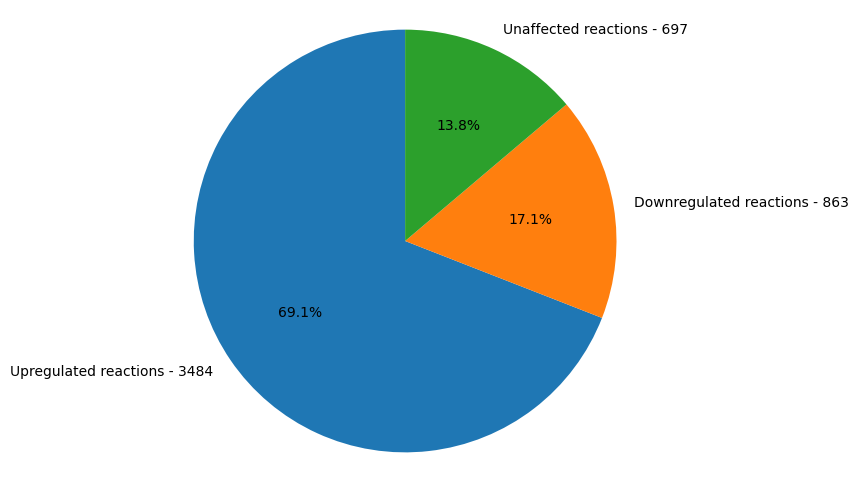

In [ ]:
total_reactions =
upregulated = 3484
downregulated = 863
unaffected = total_reactions - upregulated - downregulated



labels = [
    f"Upregulated reactions - {upregulated}",
    f"Downregulated reactions - {downregulated}",
    f"Unaffected reactions - {unaffected}"
]

sizes = [upregulated, downregulated, unaffected]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
#plt.title("MKN28_0th_non_infected_integratedvsGES_1_0th_non_infected_integrated")
plt.axis('equal')  # makes it a perfect circle
plt.savefig("MKN28_0th_non_infected_integratedvsGES_1_0th_non_infected_integrated.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>